,"pressure, atm","viscosity, cP"
0,1.000000,0.018312
1,3.010101,0.018321
2,5.020202,0.018330
3,7.030303,0.018339
4,9.040404,0.018349


,"pressure, atm","viscosity, cP",z,Bg
0,1.000000,0.018312,0.998484,1.069866
1,3.010101,0.018321,0.995444,0.354343
2,5.020202,0.018330,0.992415,0.211817
3,7.030303,0.018339,0.989398,0.150794
4,9.040404,0.018349,0.986393,0.116910


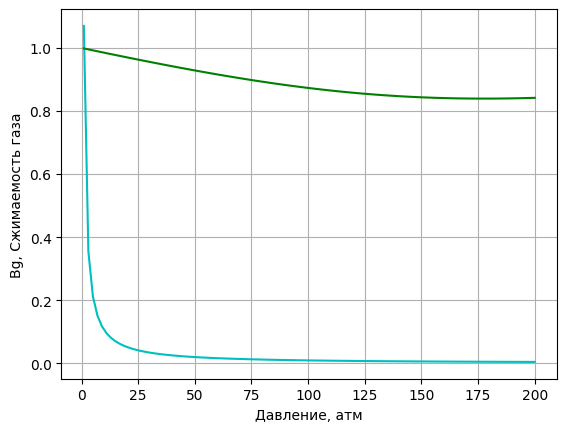

In [98]:
# Часть 1. Загрузка и обогащение данных
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

class Fluid:
    
    Pstd = 0.101325     # стандартное давление, МПа
    Tstd = 293.15       # стандартная температура, К
    
    def __init__(self, rho_c: float, xa: float, xy: float):
        self.rho_c = rho_c
        self.xa = xa/100
        self.xy = xy/100
    
    def get_Z(self, P: float, T: float) -> float:
        #Расчет фактора сжимаемости при стандартных условиях (z_c)
        z_c = 1-(0.0741*self.rho_c-0.006-0.063*self.xa-0.0575*self.xy)**2
        #Расчет молярной доли эквивалентного углеводорода (x_u в д.ед)
        x_u = 1 - self.xa - self.xy
        #Расчет молярной массы эквивалентного угле-да (M_u в д.ед)
        M_u = (24.05525*z_c*self.rho_c-28.0135*(self.xa)-44.01*(self.xy))/x_u
        #Расчет H
        H = 128.64+47.479*M_u
        #Расчет молярной плотности rho_m в кмоль/м3
            #Молярная масса газа в кг/кмоль
        M_g = M_u*x_u+28.0135*(self.xa)+44.01*(self.xy)
            #Тогда моляная плотность будет рассчитана
        rho_m = (self.rho_c/M_g)
        #Расчет коэфф-ов B1,B2 и т.д.
        B1 = (-0.425468 + 2.865e-3*T - 4.62073e-6*T**2 + (8.77118e-4 - 5.56281e-6*T + 8.8151e-9*T**2)*H
          + (-8.24747e-7 + 4.31436e-9*T - 6.08319e-12*T**2)*H**2)
        B2 = -0.1446 + 7.4091e-4*T - 9.1195e-7*T**2
        B23 = -0.339693 + 1.61176e-3*T - 2.04429e-6*T**2
        B3 = -0.86834 + 4.0376e-3*T - 5.1657e-6*T**2
        C1 = (-0.302488 + 1.95861e-3*T - 3.16302e-6*T**2
              + (6.46422e-4 - 4.22876e-6*T + 6.88157e-9*T**2)*H
              + (-3.32805e-7 + 2.2316e-9*T - 3.67713e-12*T**2)*H**2)
        C2 = 7.8498e-3 - 3.9895e-5*T + 6.1187e-8*T**2
        C3 = 2.0513e-3 + 3.4888e-5*T - 8.3703e-8*T**2
        C223 = 5.52066e-3 - 1.68609e-5*T + 1.57169e-8*T**2
        C233 = 3.58783e-3 + 8.06674e-6*T - 3.25798e-8*T**2
        B_star = 0.72 + 1.875e-5*(320 - T)**2
        C_star = 0.92 + 0.0013*(T - 270)
        Bm = (x_u**2 * B1 + x_u *  self.xa * B_star * (B1 + B2) - 1.73 * x_u *  self.xy * (B1 * B3)**0.5 
          +  self.xa**2 * B2 + 2 *  self.xa *  self.xy * B23 +  self.xy**2 * B3)
        Cm = (x_u**3 * C1 + 3 * x_u**2 *  self.xa * C_star * (C1**2 * C2)**(1/3) + 2.76 * x_u**2 *  self.xy * (C1**2 * C3)**(1/3)
          + 3 * x_u *  self.xa**2 * C_star * (C1 * C2**2)**(1/3) + 6.6 * x_u *  self.xa *  self.xy * (C1 * C2 * C3)**(1/3)
          + 2.76 * x_u *  self.xy**2 * (C1 * C3**2)**(1/3) +  self.xa**3 * C2 + 3 *  self.xa**2 *  self.xy * C223
          + 3 *  self.xa * self.xy**2 * C233 +  self.xy**3 * C3)
        b = 10**3 * (P / (2.7715*T)) # Р, МПа
        C0 = b**2 * Cm
        B0 = b * Bm
        A1 = 1 + B0
        A0 = 1 + 1.5 * (B0 + C0)
        A2 = (A0 - (A0**2 - A1**3)**0.5)**(1/3)
        #Подстановка в итоговую формулу
        Z = (1 + A2 + A1/A2) / 3
        #K = Z / z_c

        return Z

    def get_Bg(self, P: float, T: float) -> float:
        Bg = (self.Pstd * self.get_Z(P, T) * T) / ((P) * self.Tstd)
        return Bg
        
# Загрузка данных из файла

df = pd.read_csv('interp_data.csv', sep=';')
display(df.head())

# === Создание объекта Fluid (подставьте свои параметры из hw2_data.csv) ===

rho_c = 0.6799  # TODO: ваше значение плотности
xa = 0.8858     # TODO: ваша мольная доля азота
xy = 0.0668     # TODO: ваша мольная доля CO₂

fluid = Fluid(rho_c=rho_c, xa=xa, xy=xy)

# === Расчёт Z и Bg для каждого давления при T = 310 К ===

T = 310  # К
pressure_list = df['pressure, atm']/10

all_z = fluid.get_Z(pressure_list,T)
all_bg = fluid.get_Bg(pressure_list,T)

df['z'] = all_z
df['Bg'] = all_bg

plt.plot(pressure_list*10, all_bg, color='c')
plt.plot(pressure_list*10, all_z, color='g')
plt.xlabel('Давление, атм')
plt.ylabel('Bg, Сжимаемость газа')
plt.grid(True)
display(df.head())

In [99]:
#Часть 2. Собственный интерполятор
class LinearInterpolator:
    
    def __init__(self, x, y):
    # TODO: сохранить x и y, проверить что длины совпадают

        if len(x) != len(y):
            print(f'Attention - количество x,y не совпадает, x,y:{len(x),len(y)}')
            self.x = None
            self.y = None
        else:
            self.x = x
            self.y = y

            
    def predict(self, xp):
        # TODO: реализовать линейную интерполяцию
    
        # Обработка массива xp (если передан список/массив)
        if not isinstance(xp, (int, float)):
            return [self.predict(i) for i in xp]
    
        # Проверка на выход за границы диапазона (экстраполяция)
        if xp < min(self.x) or xp > max(self.x):
    
            if xp < min(self.x):  # Экстраполяция влево
                x1, y1 = self.x[0], self.y[0]      
                x2, y2 = self.x[1], self.y[1]       
            else:  # Экстраполяция вправо
                x1, y1 = self.x[-2], self.y[-2]    
                x2, y2 = self.x[-1], self.y[-1]    
    
            # Формула линейной экстраполяции
            return y1 + (xp - x1) * (y2 - y1) / (x2 - x1)
    
        # Бинарный поиск O(log n) для нахождения отрезка [x_left, x_right],
        # на котором находится xp
        left = 0
        right = len(self.x) - 1
    
        # Уточнение границ до тех пор, пока между left и right не окажется соседние индексы
        while right - left > 1:
            mid = (left + right) // 2
    
            if self.x[mid] == xp:  
                return self.y[mid]
    
            elif self.x[mid] < xp:  
                left = mid
            else:  
                right = mid
    
        # После цикла left и right - это индексы двух соседних точек, между которыми лежит xp
        x1 = self.x[left]
        x2 = self.x[right]
        y1 = self.y[left]
        y2 = self.y[right]
    
        # Формула линейной интерполяции
        return y1 + (xp - x1) * (y2 - y1) / (x2 - x1)
    

In [100]:

import time


x = df['pressure, atm']
y = df['viscosity, cP']

press_visc = np.linspace(-5, 220, 500)
viscosity = LinearInterpolator(x.tolist(), y.tolist())  # <-- .tolist() для совместимости

n_runs = 100

# --- np.interp
start = time.perf_counter()
for _ in range(n_runs):
    np.interp(press_visc, x, y)
time_np = (time.perf_counter() - start) / n_runs

# --- predict
start = time.perf_counter()
for _ in range(n_runs):
    viscosity.predict(press_visc)
time_custom = (time.perf_counter() - start) / n_runs

print(f"Среднее время np.interp: {time_np:.6e} сек")
print(f"Среднее время predict(): {time_custom:.6e} сек")

if time_np > 0:
    ratio = time_custom / time_np
    print(f"np.interp быстрее примерно в {ratio:.1f} раз")
else:
    print("Время выполнения np.interp слишком мало для корректного сравнения")

Среднее время np.interp: 3.162400e-05 сек
Среднее время predict(): 2.399260e-03 сек
np.interp быстрее примерно в 75.9 раз


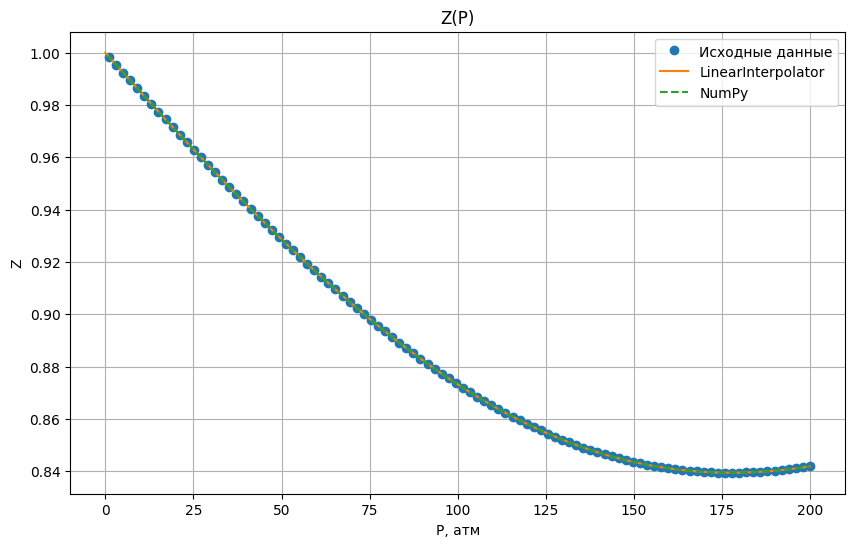

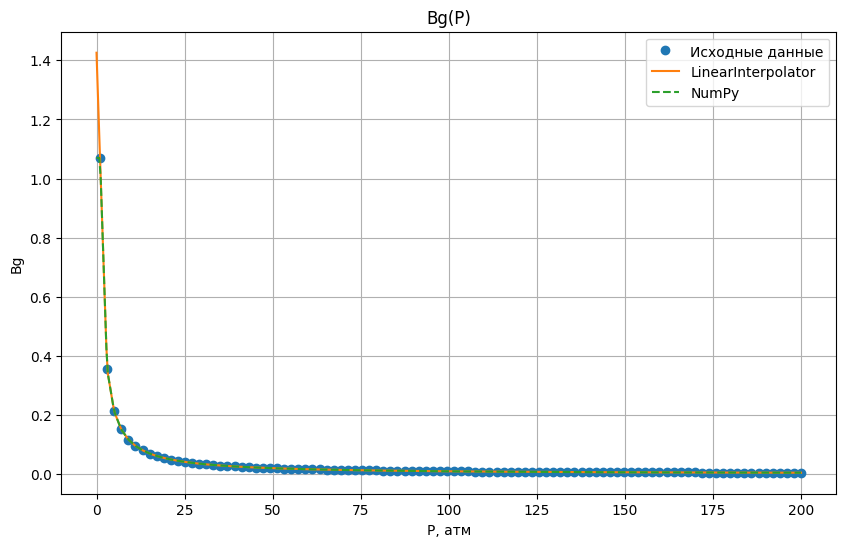

In [102]:
# === Интерполяция для Z и Bg ===
x = df['pressure, atm'].values
y_z = df['z'].values
y_bg = df['Bg'].values

press_interp = np.linspace(0, 200, 500)

# === Z ===
interp_z = LinearInterpolator(x.tolist(), y_z.tolist())
Z_custom = np.array([interp_z.predict(p) for p in press_interp])
Z_numpy = np.interp(press_interp, x, y_z)

# === Bg ===
interp_bg = LinearInterpolator(x.tolist(), y_bg.tolist())
Bg_custom = np.array([interp_bg.predict(p) for p in press_interp])
Bg_numpy = np.interp(press_interp, x, y_bg)

# === Графики ===
# Z(P)
plt.figure(figsize=(10, 6))
plt.plot(df['pressure, atm'], df['z'], 'o', label='Исходные данные', markersize=6)
plt.plot(press_interp, Z_custom, '-', label='LinearInterpolator', linewidth=1.5)
plt.plot(press_interp, Z_numpy, '--', label='NumPy', linewidth=1.5)
plt.title('Z(P)'), plt.xlabel('P, атм'), plt.ylabel('Z'), plt.grid(), plt.legend()

# Bg(P)
plt.figure(figsize=(10, 6))
plt.plot(df['pressure, atm'], df['Bg'], 'o', label='Исходные данные', markersize=6)
plt.plot(press_interp, Bg_custom, '-', label='LinearInterpolator', linewidth=1.5)
plt.plot(press_interp, Bg_numpy, '--', label='NumPy', linewidth=1.5)
plt.title('Bg(P)'), plt.xlabel('P, атм'), plt.ylabel('Bg'), plt.grid(), plt.legend()

plt.show()